111 m, c = [2.52110519e+05 4.40523538e+01]
200 m, c = [1.35471669e+05 6.35134846e+01]
311 m, c = [1.85224886e+05 4.95687797e+01]


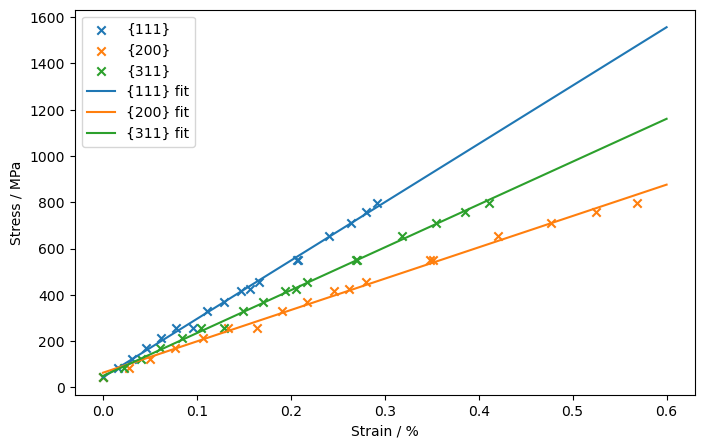

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

df = pd.read_csv("C14_data.csv", header=0, sep=r'\s+')

l = 1.5*10**(-3)
w = 2.0*10**(-3)
lda = 0.143*10**(-10)
d0_111 = lda / (2*np.sin(0.5*np.pi/180*df["2t{111}"][0]))
d0_200 = lda / (2*np.sin(0.5*np.pi/180*df["2t{200}"][0]))
d0_311 = lda / (2*np.sin(0.5*np.pi/180*df["2t{311}"][0]))

df["Stress/MPa"] = df["Load/kN"] / (l*w*10**3)
df["LatticeStrain{111}"] = (lda / (2*np.sin(0.5*np.pi/180*df["2t{111}"])))/d0_111 - 1
df["LatticeStrain{200}"] = (lda / (2*np.sin(0.5*np.pi/180*df["2t{200}"])))/d0_200 - 1
df["LatticeStrain{311}"] = (lda / (2*np.sin(0.5*np.pi/180*df["2t{311}"])))/d0_311 - 1


def func(data, p1, p2):
    return p1*data + p2
popt1, pcov1 = curve_fit(func, df["LatticeStrain{111}"], df["Stress/MPa"])
popt2, pcov2 = curve_fit(func, df["LatticeStrain{200}"], df["Stress/MPa"])
popt3, pcov3 = curve_fit(func, df["LatticeStrain{311}"], df["Stress/MPa"])
x_fine = np.linspace(0,0.006,1000)
print(f"{111} m, c = {popt1}")
print(f"{200} m, c = {popt2}")
print(f"{311} m, c = {popt3}")

plt.figure(figsize=(8,5))
plt.scatter(100*df["LatticeStrain{111}"], df["Stress/MPa"], label="{111}", marker="x")
plt.scatter(100*df["LatticeStrain{200}"], df["Stress/MPa"], label="{200}", marker="x")
plt.scatter(100*df["LatticeStrain{311}"], df["Stress/MPa"], label="{311}", marker="x")
plt.plot(100*x_fine, func(x_fine, popt1[0], popt1[1]), label="{111} fit")
plt.plot(100*x_fine, func(x_fine, popt2[0], popt2[1]), label="{200} fit")
plt.plot(100*x_fine, func(x_fine, popt3[0], popt3[1]), label="{311} fit")
plt.xlabel("Strain / %")
plt.ylabel("Stress / MPa")
plt.legend()
plt.show()